# Plots for survival analyses

Time-to-event data, commonly referred to as survival data, quantifies the duration until a specified event occurs. In clinical research contexts, this might encompass time to death, disease recurrence, or treatment failure. The defining characteristic of such data is **censoring**—observations wherein the event has not materialised by the study's conclusion, thereby providing incomplete yet valuable information.

#### Key analytical quantities

These data are typically analysed to estimate several related quantities:

The **survival function** represents the probability that a subject remains event-free at any given time point. The complementary **cumulative incidence** represents the probability that an event has occurred by a specified time.

Related to these are the **hazard** and **cumulative hazard functions**. The hazard represents the instantaneous rate at which an event occurs at any given moment, whilst the cumulative hazard reflects the accumulated hazard up to a particular time point.

*Note*: Whilst **survival** and **incidence** estimates represent probabilities bounded between 0 and 1, **(cumulative) hazard** estimates reflect rates (the number of events per unit time) and are therefore bounded only by zero, potentially exceeding unity.

#### Visualisation types

Depending upon the methodological approach—whether (semi-)parametric or non-parametric—these quantities are typically depicted either as smooth curves or step-wise functions, respectively.

#### Rationale for this module

Packages like `lifelines` already include excellent plotting tools built into their results objects. However, these plotting functions do not usually let you supply your own data directly. This means you cannot separate the analysis from the plotting, which is often needed when scaling up analyses.This module fills that gap: once you have run and saved multiple survival analyses, the tools provided here will help you create illustrations of your results.

In the following, we will focus on depicting a step-wise survival function using a survival plot—for example, used to depict the Kaplan-Meier estimate over time.
For this, we will first simulate a survival estimate against time.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plot_misc.example_data.examples as examples
import plot_misc.survival as pltm_surv

surv_table = examples.create_survival_data(nrows=24)
surv_table

,survival_estimate,lower_ci_95,upper_ci_95,at_risk
time,,,,
0.000000,1.000000,0.850000,1.000000,1000
4.347826,0.915334,0.778034,1.000000,915
8.695652,0.846847,0.719820,0.973874,846
13.043478,0.785612,0.667770,0.903453,785
17.391304,0.703880,0.598298,0.809462,703
21.739130,0.645064,0.548304,0.741824,645
26.086957,0.609280,0.517888,0.700672,609
30.434783,0.551734,0.468974,0.634495,551
34.782609,0.494054,0.419946,0.568162,494


## Basic survival plot

A step-wise function is the standard representation for non-parametric estimates such as the Kaplan-Meier curve, where the survival function only changes at observed event times. 

In the example below we generate a basic step-wise survival curve with a single line.

Text(0.5, 0, 'Time (days)')

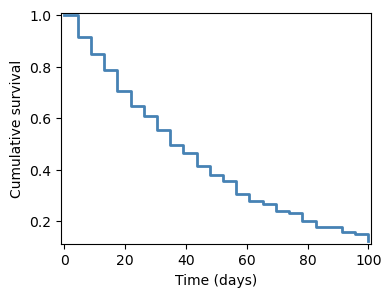

In [2]:
fig, ax = plt.subplots(1, figsize=(4, 3))
_, ax = pltm_surv.plot_step_wise(surv_table, estimate_col="survival_estimate", ax=ax)
ax.set_ylabel("Cumulative survival")
ax.set_xlabel("Time (days)")

### Adding confidence intervals
Next we will add a confidence interval to indicate how precise our estimate is. At first we will simply match the style of the plotted line, next we will apply  additional customisations and illustrate one-sided confidence intervals. 

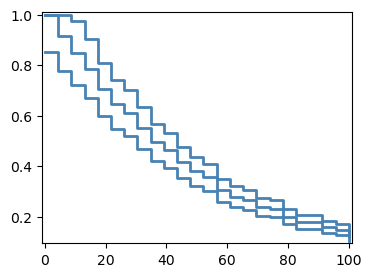

In [3]:
fig, ax = plt.subplots(1, figsize=(4, 3))
_, ax = pltm_surv.plot_step_wise(
    surv_table,
    estimate_col="survival_estimate",
    lower_ci_col="lower_ci_95",
    upper_ci_col="upper_ci_95",
    ax=ax,
)

Here it is not very clear which lines are the confidence interval and which line is the point estimate. To make this distinction clearer we will change the linestyle, the width, and the colour of the confidence intervals.

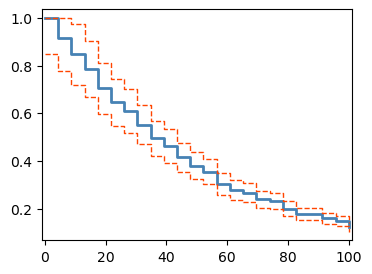

In [4]:
fig, ax = plt.subplots(1, figsize=(4, 3))
_, ax = pltm_surv.plot_step_wise(
    surv_table,
    estimate_col="survival_estimate",
    lower_ci_col="lower_ci_95",
    upper_ci_col="upper_ci_95",
    line_colour_ci="orangered",
    line_width_ci=1,
    line_style_ci="--",
    ax=ax,
    margins=(0.01, 0.04),
)

Finally we illustrate how one can plot a single side of the confidence interval (i.e. for a one-sided hypothesis).

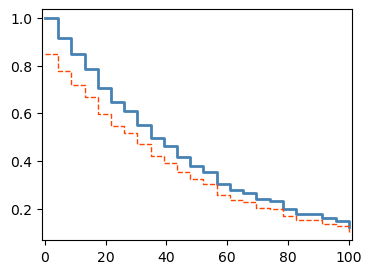

In [5]:
fig, ax = plt.subplots(1, figsize=(4, 3))
_, ax = pltm_surv.plot_step_wise(
    surv_table,
    estimate_col="survival_estimate",
    lower_ci_col="lower_ci_95",
    line_colour_ci="orangered",
    line_width_ci=1,
    line_style_ci="--",
    ax=ax,
    margins=(0.01, 0.04),
)

### Adding a fill between the confidence interval limits

In addition to marking the confidence interval limits we can also fill the area between these limits. 

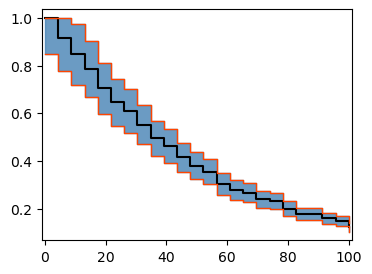

In [6]:
fig, ax = plt.subplots(1, figsize=(4, 3))
_, ax = pltm_surv.plot_step_wise(
    surv_table,
    estimate_col="survival_estimate",
    lower_ci_col="lower_ci_95",
    upper_ci_col="upper_ci_95",
    line_colour="black",
    line_width=1.5,
    line_colour_ci="orangered",
    line_width_ci=1,
    fill=True,
    fill_colour="steelblue",
    ax=ax,
    margins=(0.01, 0.04),
)

A one-sided fill is also supported. When only `upper_ci_col` is supplied (and `lower_ci_col` is omitted), the shaded region spans from the point estimate line up to the upper bound. This is appropriate for one-sided hypothesis tests, where only one bound is of substantive interest.

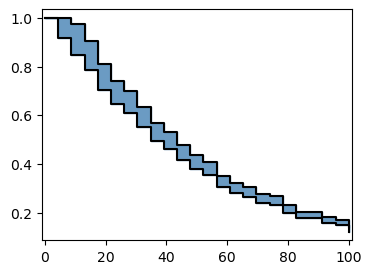

In [7]:
fig, ax = plt.subplots(1, figsize=(4, 3))
_, ax = pltm_surv.plot_step_wise(
    surv_table,
    estimate_col="survival_estimate",
    upper_ci_col="upper_ci_95",
    line_colour="black",
    line_width=1.5,
    line_width_ci=1.5,
    fill=True,
    fill_colour="steelblue",
    ax=ax,
    margins=(0.01, 0.04),
)



While it often is aesthetically pleasing to include the confidence interval outline, one can simply remove this be setting `line_width_ci` to zero. 

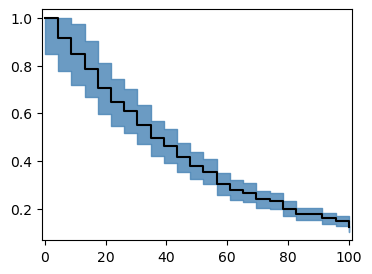

In [8]:
fig, ax = plt.subplots(1, figsize=(4, 3))
_, ax = pltm_surv.plot_step_wise(
    surv_table,
    estimate_col="survival_estimate",
    lower_ci_col="lower_ci_95",
    upper_ci_col="upper_ci_95",
    line_colour="black",
    line_width=1.5,
    line_width_ci=0,
    fill=True,
    fill_colour="steelblue",
    ax=ax,
    margins=(0.01, 0.04),
)

## Plotting the survival function for multiple groups

To plot the survival function for multiple groups we simply add multiple lines using the `add` parameter ensuring the `axes` formatting does not change between lines. Note we will also truncate the follow-up time to focus on first 80 days.

Text(0.5, 0, 'Time (days)')

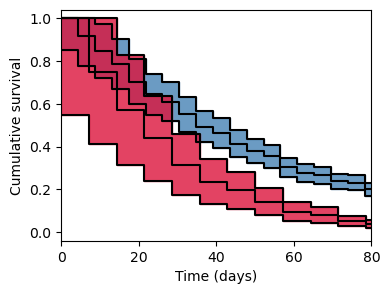

In [9]:
surv_table2 = examples.create_survival_data(nrows=15, survival_rate=0.04, ci_width=0.45)
fig, ax = plt.subplots(1, figsize=(4, 3))
_, _ = pltm_surv.plot_step_wise(
    surv_table,
    estimate_col="survival_estimate",
    line_width=1.5,
    line_colour="black",
    lower_ci_col="lower_ci_95",
    upper_ci_col="upper_ci_95",
    line_width_ci=1.5,
    fill_colour="steelblue",
    fill=True,
    ax=ax,
    xlim=(0, 80),
    margins=(0.01, 0.04),
)
_, _ = pltm_surv.plot_step_wise(
    surv_table2,
    estimate_col="survival_estimate",
    line_colour="black",
    line_width=1.5,
    lower_ci_col="lower_ci_95",
    upper_ci_col="upper_ci_95",
    line_width_ci=1.5,
    fill_colour="crimson",
    fill=True,
    ax=ax,
    add=True,
)
ax.set_ylabel("Cumulative survival")
ax.set_xlabel("Time (days)")

# Survival plot with risk table

The **risk table** (or at-risk table) appears beneath the survival plot, showing the number of subjects still under observation at selected time points. This table can be expanded by adding multiple rows per line or by adding the cumulative number of subjects with an event and/or the number of subjects who were censored. 

Use `extract_follow_up` to pull the at-risk counts at specified time points, then `plot_table` to render them as a formatted text table below the main axes.

In [10]:
# preparing the table
bottom_table1 = pltm_surv.extract_follow_up(
    surv_table,
    at_risk_col="at_risk",
    points=[0, 50, 100],
)
bottom_table2 = pltm_surv.extract_follow_up(
    surv_table2,
    at_risk_col="at_risk",
    points=[0, 50, 100],
)

# merge tables
sel_col = ["time", "group_1_at_risk_format"]
col_names = ["time", "group 1", "group 2"]
bottom_table = pd.merge(bottom_table1[sel_col], bottom_table2[sel_col], on=["time"])
bottom_table.columns = col_names
bottom_table

,time,group 1,group 2
0,0,"1,000","1,000"
1,50,379,143
2,100,121,1


Text(0.5, 0, 'Time (days)')

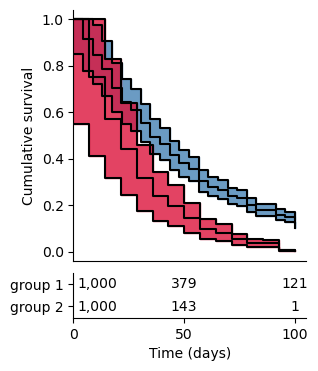

In [11]:
f, axs = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(3, 4),
    gridspec_kw={"height_ratios": [10, 1.8]},
    sharex=False,
)
plt.subplots_adjust(hspace=0.08)

# the survival curve
_, _ = pltm_surv.plot_step_wise(
    surv_table,
    estimate_col="survival_estimate",
    line_width=1.5,
    line_colour="black",
    lower_ci_col="lower_ci_95",
    upper_ci_col="upper_ci_95",
    line_width_ci=1.5,
    fill_colour="steelblue",
    fill=True,
    ax=axs[0],
    xlim=(0, 80),
    margins=(0.01, 0.04),
)
_, _ = pltm_surv.plot_step_wise(
    surv_table2,
    estimate_col="survival_estimate",
    line_colour="black",
    line_width=1.5,
    lower_ci_col="lower_ci_95",
    upper_ci_col="upper_ci_95",
    line_width_ci=1.5,
    fill_colour="crimson",
    fill=True,
    ax=axs[0],
    add=True,
)

# adding the table
xlims = (0, 105)
axs[0].set_xlim(xlims)
axs[1].set_xlim(xlims)
_ = pltm_surv.plot_table(
    bottom_table,
    ax=axs[1],
    string_col=col_names[1:],
    yticklabel=col_names[1:],
    size_text=10,
    yloc=[0.25, 0.75],
    xticklabel=bottom_table[col_names[0]].to_list(),
    xtickloc=bottom_table[col_names[0]].to_list(),
    pad_first=11,
)

# formatting
axs[0].spines[["top", "right"]].set_visible(False)
axs[0].set_ylabel("Cumulative survival")
axs[0].set_xticks([])
axs[1].set_xlabel("Time (days)")